# ESP polar scan

The purpose of this jupyter notebook is to visualize the pickle files generated from the `chlorophyll-analyzer` script.

Just as reminder, these are the ring substituent in known chlorophyll types:

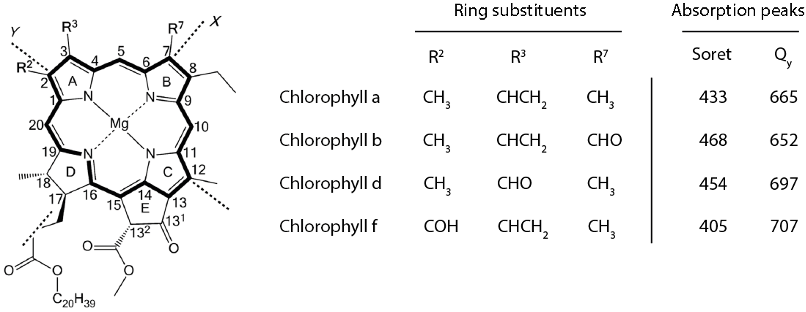

After importing the packages and the .pickle generated from the script you'll be able to take a look at specific "cones" as well as to analyze the performance on a given Map/Model combination. The results obtained have to be interpreted together with structural analysis and are supposed to be just an extra aid to other lines of evidence.

If anything is not clear, you have any questions or suggestions get in touch with me at gconsoli@ic.ac.uk

## Setup

Install the notebook dependencies from the project root with:

```
uv sync --group notebook
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import skew

# Set seaborn styling
sns.set_theme()
sns.set_context("talk")
sns.set_style("ticks")

## Constants and helpers

The scan grid below mirrors the analyzer's default `cone` geometry: 26 distances
from 0 to 2.5 Å, each scanned over 72 angles.

In [2]:
DATA_DIR = Path("../data")
SUBSTITUENTS = ["C2", "C3", "C7", "C8", "C12"]

MAX_DISTANCE = 2.5
N_DISTANCES = 26
N_ANGLES = 72
GRID_SHAPE = (N_DISTANCES, N_ANGLES)
DISTANCES = np.round(np.linspace(0, MAX_DISTANCE, N_DISTANCES), decimals=1)

# Polar mesh shared by every plot. Angles are offset by -pi/2 so that 0 degrees
# points up rather than right.
THETA = np.linspace(0, 2 * np.pi, N_ANGLES, endpoint=False) - np.pi / 2
THETA_GRID, R_GRID = np.meshgrid(THETA, DISTANCES)

# Closed version (first point repeated at 2*pi) for drawing full gridline circles.
THETA_CLOSED = np.linspace(0, 2 * np.pi, N_ANGLES)


def load_scan(structure: str, kind: str, geometry: str = "cone") -> pd.DataFrame:
    # Load one pickle written by the analyzer, e.g. kind="data" or "zscores".
    path = DATA_DIR / structure / f"{structure}_{geometry}_{kind}.pickle"
    scan = pd.read_pickle(path)
    if not isinstance(scan, pd.DataFrame):
        raise TypeError(f"{path} does not hold a DataFrame.")
    return scan

In [3]:
def get_statistics_df(
    df: pd.DataFrame,
    selected_data: list[str],
    lower_bound: float = 0.0,
    upper_bound: float = np.inf,
) -> pd.DataFrame:
    # Average and standard deviation per substituent, over the chlorophylls whose
    # 'loc_res_Mg' falls within the given bounds.
    filtered_df = df[
        (df["loc_res_Mg"] >= lower_bound) & (df["loc_res_Mg"] <= upper_bound)
    ]
    if filtered_df.empty:
        raise ValueError("No rows match the filtering criteria. Adjust the boundaries.")

    stats_df = pd.DataFrame(index=["Average", "Standard Deviation"])
    for column in selected_data:
        # Stack the per-chlorophyll grids along a new leading axis so the
        # reductions collapse that axis and keep the (26, 72) grid shape.
        grids = np.stack(filtered_df[column].to_numpy())
        stats_df[column] = [grids.mean(axis=0), grids.std(axis=0)]

    return stats_df


def get_zscores_df(
    df: pd.DataFrame, stats_df: pd.DataFrame, ref_substituent: str
) -> pd.DataFrame:
    # Score every substituent against the mean and standard deviation of the
    # reference substituent (e.g. "C7").
    mean_value = stats_df.at["Average", ref_substituent]
    std_value = stats_df.at["Standard Deviation", ref_substituent]

    zscores_df = pd.DataFrame(index=df.index, columns=SUBSTITUENTS)
    for row_idx, row in df.iterrows():
        for substituent in SUBSTITUENTS:
            zscores_df.loc[row_idx, substituent] = (
                row[substituent] - mean_value
            ) / std_value

    return zscores_df

In [4]:
def _rows_within(distance: float) -> int:
    # Number of leading grid rows covering `distance`, out of the 26 scanned.
    return int((distance / MAX_DISTANCE) * N_DISTANCES)


def print_extreme_values(df: pd.DataFrame, row: str, column: str) -> None:
    # Print the highest and lowest values for a given Chl substituent.
    array = df.at[row, column]
    print(f"Highest Z-score value: {np.max(array)}")
    print(f"Lowest Z-score value: {np.min(array)}")


def count_outliers(
    df: pd.DataFrame, cutoff: float, distance: float = MAX_DISTANCE
) -> pd.Series:
    # Count the cells holding an outlier, considering only rows up to `distance`.
    max_row = _rows_within(distance)

    def has_outliers(arr: np.ndarray) -> bool:
        sliced_arr = arr[:max_row, :]
        return bool(np.any((sliced_arr > cutoff) | (sliced_arr < -cutoff)))

    return df.map(has_outliers).sum()


def find_outlier_chlorophylls(
    df: pd.DataFrame,
    column: str,
    cutoff: float = 3,
    distance: float = MAX_DISTANCE,
) -> list[str]:
    # Chlorophylls whose values exceed the cutoff within `distance`.
    max_row = _rows_within(distance)
    outlier_chlorophylls = []
    for chlorophyll in df.index:
        data_subset = df.at[chlorophyll, column][:max_row, :]
        if np.any((data_subset > cutoff) | (data_subset < -cutoff)):
            outlier_chlorophylls.append(chlorophyll)
    return outlier_chlorophylls

In [5]:
def polar_plot_df(df: pd.DataFrame, cmap: str = "RdBu_r") -> None:
    # One row of polar plots per DataFrame row, sharing a symmetric colour scale.
    num_columns = df.shape[1]
    figure_width = 6 * num_columns

    for row_label in df.index:
        fig, axes = plt.subplots(
            1,
            num_columns,
            figsize=(figure_width, 5),
            subplot_kw={"projection": "polar"},
        )
        axes = np.atleast_1d(axes).flatten()

        # Validate and collect all values for scaling
        all_values = []
        for i, column in enumerate(df.columns):
            data = df.at[row_label, column]
            if isinstance(data, np.ndarray) and data.ndim == 2:
                all_values.append(data.flatten())
            else:
                # Hide subplot if the data is invalid
                axes[i].set_visible(False)

        if all_values:
            max_value = np.max(np.abs(np.concatenate(all_values)))

            # Plot each heatmap
            for i, column in enumerate(df.columns):
                data = df.at[row_label, column]
                if isinstance(data, np.ndarray) and data.ndim == 2:
                    cax = axes[i].pcolormesh(
                        THETA_GRID,
                        R_GRID,
                        data,
                        cmap=cmap,
                        vmin=-max_value,
                        vmax=max_value,
                        shading="auto",
                    )
                    fig.colorbar(cax, ax=axes[i], pad=0.15)
                    axes[i].set_title(f"{row_label} - {column}")
                else:
                    # Set title for invalid data
                    axes[i].set_title(f"{row_label} - {column} (Invalid Data)")
        else:
            print(f"Skipping row {row_label} as all data is invalid.")

        # Display the plots
        fig.tight_layout()
        plt.show()


def polar_plot_substituent(
    df1: pd.DataFrame,
    df2: pd.DataFrame,
    chlorophyll_numbers: list[str],
    substituent: str,
) -> None:
    # Side-by-side ESP (df1) and Z-score (df2) polar plots for each chlorophyll.
    figure_width = 15
    vmin2, vmax2 = -5, 5

    for chlorophyll_number in chlorophyll_numbers:
        data_test = df1.at[chlorophyll_number, substituent]
        data_zscore = df2.at[chlorophyll_number, substituent]

        fig, axs = plt.subplots(
            1, 2, figsize=(figure_width, 5), subplot_kw={"projection": "polar"}
        )

        # Plot for df1 (ESP data), scaled symmetrically around its largest value
        max_abs_test = np.max(np.abs(data_test))
        cax_test = axs[0].pcolormesh(
            THETA_GRID,
            R_GRID,
            data_test,
            cmap="RdBu_r",
            vmin=-max_abs_test,
            vmax=max_abs_test,
            shading="auto",
        )
        cb_test = fig.colorbar(cax_test, ax=axs[0], pad=0.15)
        cb_test.set_label("ESP (A.U.)")
        axs[0].set_title(f"{chlorophyll_number} - {substituent} - map ESP", y=1.1)
        axs[0].set_yticklabels([])

        # Plot for df2 (Z-score data), on a fixed scale so plots stay comparable
        cax_zscore = axs[1].pcolormesh(
            THETA_GRID,
            R_GRID,
            data_zscore,
            cmap="Spectral_r",
            vmin=vmin2,
            vmax=vmax2,
            shading="auto",
        )
        cb_zscore = fig.colorbar(cax_zscore, ax=axs[1], pad=0.15)
        cb_zscore.set_label("Z-score")
        axs[1].set_title(f"{chlorophyll_number} - {substituent} - Z score", y=1.1)
        axs[1].set_yticklabels([])

        # Add gridlines manually
        for radius in np.linspace(0, 1, 5):
            for ax in axs:
                ax.plot(
                    THETA_CLOSED,
                    [radius] * N_ANGLES,
                    color="grey",
                    alpha=0.2,
                    linewidth=0.5,
                )

        plt.subplots_adjust(top=1.2)
        fig.tight_layout()
        plt.show()

In [6]:
def plot_metrics_over_cutoffs(
    df: pd.DataFrame,
    start_cutoff: float = 1,
    end_cutoff: float = 5,
    step: float = 0.1,
    distance: float = MAX_DISTANCE,
) -> None:
    # Precision, recall, accuracy and F1 over a range of Z-score cutoffs.
    # C3 and C8 are the substituents expected to deviate, so outliers there count
    # as true positives; C7 and C12 are controls, where outliers are false ones.
    cutoffs = np.arange(start_cutoff, end_cutoff + step, step)
    precisions, recalls, accuracies, f1_scores = [], [], [], []

    for cutoff in cutoffs:
        results = count_outliers(df, cutoff, distance=distance)
        chlorophylls = len(df)

        true_positives_C3_C8 = results["C3"] + results["C8"]
        false_negatives_C3_C8 = chlorophylls * 2 - true_positives_C3_C8
        false_positives_C7_C12 = results["C7"] + results["C12"]
        true_negatives_C7_C12 = chlorophylls * 2 - false_positives_C7_C12

        precision = (
            true_positives_C3_C8 / (true_positives_C3_C8 + false_positives_C7_C12)
        ) * 100
        recall = (
            true_negatives_C7_C12 / (true_negatives_C7_C12 + false_negatives_C3_C8)
        ) * 100
        accuracy = (
            (true_positives_C3_C8 + true_negatives_C7_C12) / (chlorophylls * 4)
        ) * 100

        # Avoid division by zero if both precision and recall are zero
        f1 = (
            2 * (precision * recall) / (precision + recall)
            if precision + recall > 0
            else 0
        )

        precisions.append(precision)
        recalls.append(recall)
        accuracies.append(accuracy)
        f1_scores.append(f1)

    plt.figure(figsize=(12, 6))
    plt.plot(cutoffs, precisions, label="Precision")
    plt.plot(cutoffs, recalls, label="Recall")
    plt.plot(cutoffs, accuracies, label="Accuracy")
    plt.plot(cutoffs, f1_scores, label="F1 Score")

    plt.xlabel("Cutoff Z-score")
    plt.ylabel("Percentage (%)")
    plt.title("Performance Metrics over Cutoff Values")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_loc_res_mg_with_outliers(
    df: pd.DataFrame,
    outliers: list[str],
    figsize: tuple[float, float] = (20, 8),
) -> None:
    # Per-chlorophyll Mg local resolution, with outlier rows coloured differently.
    if "loc_res_Mg" not in df.columns:
        raise ValueError("Column 'loc_res_Mg' is not in the DataFrame.")

    # Sort by loc_res_Mg for visualization purposes
    sorted_df = df.sort_values(by="loc_res_Mg")
    colors = ["orange" if idx in outliers else "blue" for idx in sorted_df.index]

    plt.figure(figsize=figsize)
    sns.scatterplot(
        x=sorted_df.index,
        y=sorted_df["loc_res_Mg"],
        s=100,
        c=colors,
        edgecolor="black",
    )

    plt.title("Values of loc_res_Mg for Each Row (Outliers Highlighted)", fontsize=16)
    plt.xlabel("Row Labels (Sorted by loc_res_Mg)", fontsize=14)
    plt.ylabel("loc_res_Mg", fontsize=14)
    plt.xticks(rotation=45, fontsize=12, ha="right")
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.show()


def plot_loc_res_mg_distribution(
    df: pd.DataFrame,
    bins: int = 20,
    kde: bool = True,
    figsize: tuple[float, float] = (10, 6),
) -> None:
    # Distribution of the per-chlorophyll Mg local resolution.
    if "loc_res_Mg" not in df.columns:
        raise ValueError("Column 'loc_res_Mg' is not in the DataFrame.")

    plt.figure(figsize=figsize)
    sns.histplot(
        df["loc_res_Mg"],
        bins=bins,
        kde=kde,  # Add a KDE curve if desired
        color="green",
        edgecolor="black",
    )

    plt.title("Distribution of loc_res_Mg Values", fontsize=16)
    plt.xlabel("loc_res_Mg", fontsize=14)
    plt.ylabel("Frequency", fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylim(0, 60)
    plt.tight_layout()
    plt.show()


def analyze_min_max_distributions(
    df: pd.DataFrame,
    column_name: str,
    row_range: tuple[int, int] = (0, N_DISTANCES),
) -> pd.DataFrame:
    # Min/max distribution of each grid, limited to the given range of distance
    # rows. Returns the extracted values.
    start, end = row_range
    max_values, min_values = [], []

    for array in df[column_name]:
        if not (isinstance(array, np.ndarray) and array.shape == GRID_SHAPE):
            raise ValueError(
                f"Unexpected data format in column {column_name}: "
                f"Expected {GRID_SHAPE} arrays."
            )
        selected_region = array[start:end, :]  # Select the specified rows
        max_values.append(selected_region.max())
        min_values.append(selected_region.min())

    extracted_df = pd.DataFrame({"Max Values": max_values, "Min Values": min_values})

    for label in ("Max Values", "Min Values"):
        values = extracted_df[label]
        print(
            f"{label} - Skewness: {skew(values):.3f}, "
            f"Mean: {values.mean():.3f}, Median: {values.median():.3f}"
        )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.histplot(
        extracted_df["Min Values"], kde=True, bins=30, ax=axes[0], color="#17BEBB"
    )
    axes[0].set_title(f"Distribution of Min Values (Rows {start}-{end - 1})")
    sns.histplot(
        extracted_df["Max Values"], kde=True, bins=30, ax=axes[1], color="#EF3E36"
    )
    axes[1].set_title(f"Distribution of Max Values (Rows {start}-{end - 1})")

    fig.tight_layout()
    plt.show()

    return extracted_df

## Load the data

Point `STRUCTURE` at any subdirectory of `data/`.

In [7]:
STRUCTURE = "9EYS"

PSII_esp = load_scan(STRUCTURE, "data")
PSII_zscores = load_scan(STRUCTURE, "zscores")
PSII_stats = load_scan(STRUCTURE, "stats")

PSII_esp

,loc_res_Mg,C2,C3,C7,C8,C12
A1011,2.063040,"[[0.18885875881948114, 0.18885875881948114, 0....","[[0.2170044728072491, 0.2170044728072491, 0.21...","[[0.19199072057458, 0.19199072057458, 0.191990...","[[0.2400915009642374, 0.2400915009642374, 0.24...","[[0.1914613118843722, 0.1914613118843722, 0.19..."
A1012,2.063040,"[[0.22586994003191996, 0.22586994003191996, 0....","[[0.23489989557081928, 0.23489989557081928, 0....","[[0.22508099609023605, 0.22508099609023605, 0....","[[0.22861574032150805, 0.22861574032150805, 0....","[[0.21928402940713038, 0.21928402940713038, 0...."
A1013,2.063040,"[[0.18936714958526885, 0.18936714958526885, 0....","[[0.1975057275944331, 0.1975057275944331, 0.19...","[[0.21001866564341967, 0.21001866564341967, 0....","[[0.22396173424658, 0.22396173424658, 0.223961...","[[0.1861531127408069, 0.1861531127408069, 0.18..."
A1101,2.163435,"[[0.08613864739908027, 0.08613864739908027, 0....","[[0.12302138628074555, 0.12302138628074555, 0....","[[0.11510311245641965, 0.11510311245641965, 0....","[[0.15590163435853835, 0.15590163435853835, 0....","[[0.13688875003084902, 0.13688875003084902, 0...."
A1102,2.073102,"[[0.13142010052140082, 0.13142010052140082, 0....","[[0.15594159020219442, 0.15594159020219442, 0....","[[0.11641725652408189, 0.11641725652408189, 0....","[[0.16275511481097354, 0.16275511481097354, 0....","[[0.14909102023273585, 0.14909102023273585, 0...."
...,...,...,...,...,...,...
K6004,2.481906,"[[0.04665810128185789, 0.04665810128185789, 0....","[[0.0670823991648138, 0.0670823991648138, 0.06...","[[0.056838596630326754, 0.056838596630326754, ...","[[0.07266061822641354, 0.07266061822641354, 0....","[[0.06019452561630988, 0.06019452561630988, 0...."
L1501,2.063040,"[[0.17398237924738774, 0.17398237924738774, 0....","[[0.20394791586475883, 0.20394791586475883, 0....","[[0.1820326698237639, 0.1820326698237639, 0.18...","[[0.1969232456809203, 0.1969232456809203, 0.19...","[[0.17806160514704555, 0.17806160514704555, 0...."
L1502,2.063040,"[[0.181969507640896, 0.181969507640896, 0.1819...","[[0.1794198012768922, 0.1794198012768922, 0.17...","[[0.18736088908472123, 0.18736088908472123, 0....","[[0.21167901817306772, 0.21167901817306772, 0....","[[0.2015754872382458, 0.2015754872382458, 0.20..."
L1503,2.063036,"[[0.2359522858870755, 0.2359522858870755, 0.23...","[[0.16602602936894983, 0.16602602936894983, 0....","[[0.15139350219031797, 0.15139350219031797, 0....","[[0.19574613903857227, 0.19574613903857227, 0....","[[0.15225245643609708, 0.15225245643609708, 0...."


# Calculating the average and standard deviation of each substituent

this box recalculates the average and standard deviation of all the Chl substituents, then calculates a dataframe containing the Z-scores for each of the pigments based the Ave and Std of a substituent of choice.

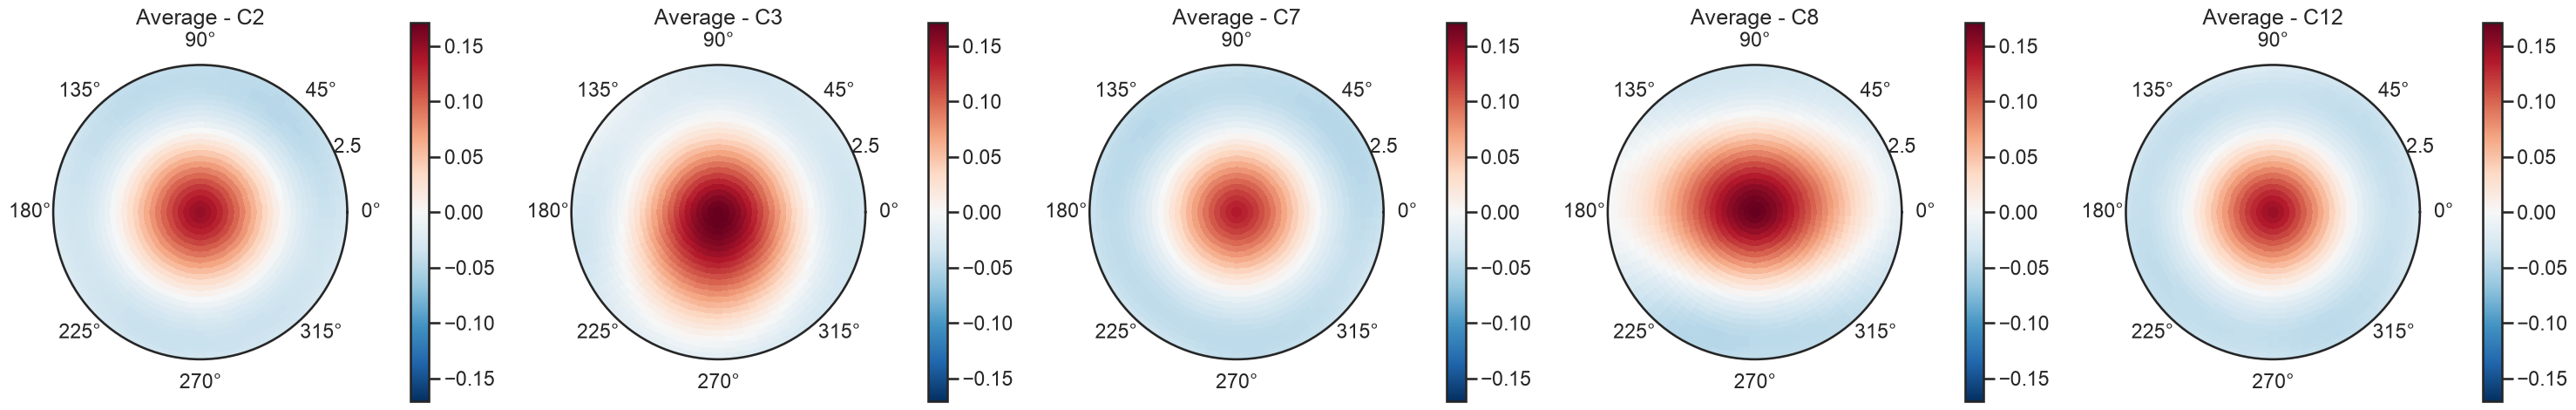

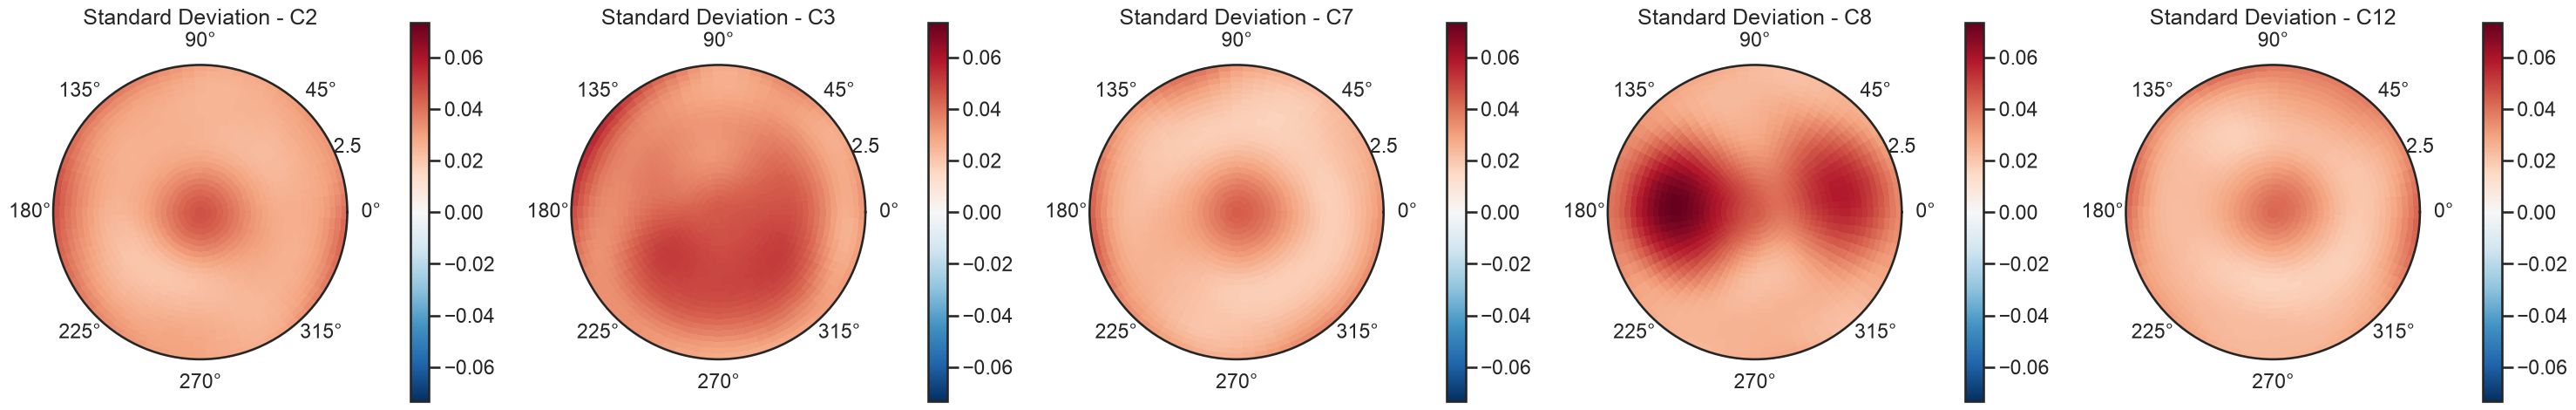

In [8]:
df_stats_filtered = get_statistics_df(PSII_esp, SUBSTITUENTS, 0, 3)

# Generate the z-scores DataFrame
zscores_df = get_zscores_df(PSII_esp, df_stats_filtered, "C7")

polar_plot_df(df_stats_filtered, cmap="RdBu_r")

# Distribution of Chl local resolution in a map

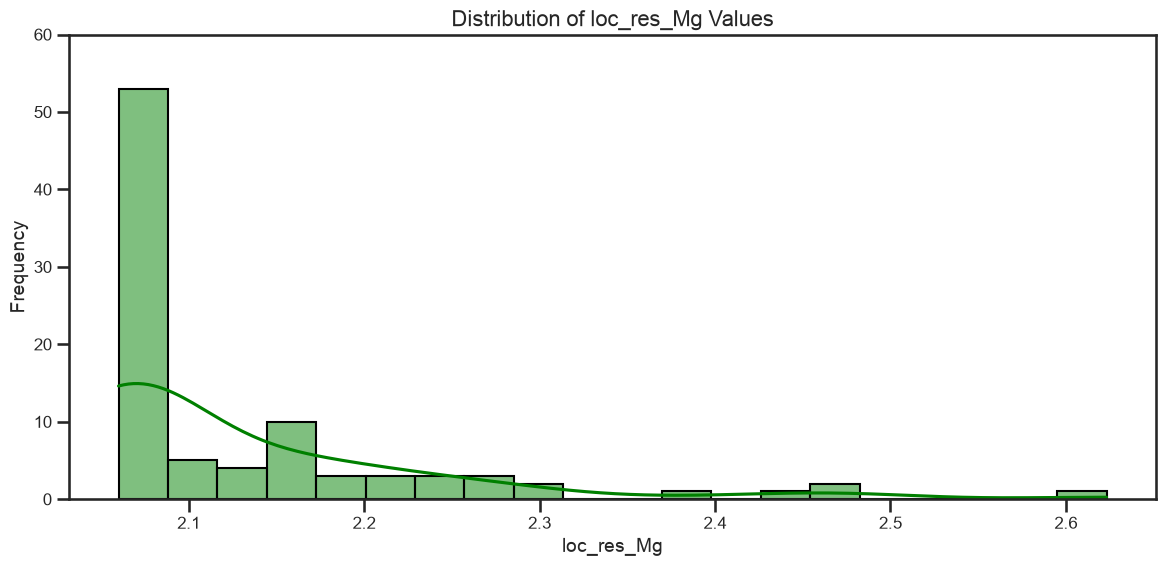

In [9]:
plot_loc_res_mg_distribution(PSII_esp, bins=20, kde=True, figsize=(12, 6))

Max Values - Skewness: 0.968, Mean: 2.262, Median: 2.126
Min Values - Skewness: -0.565, Mean: -1.813, Median: -1.714


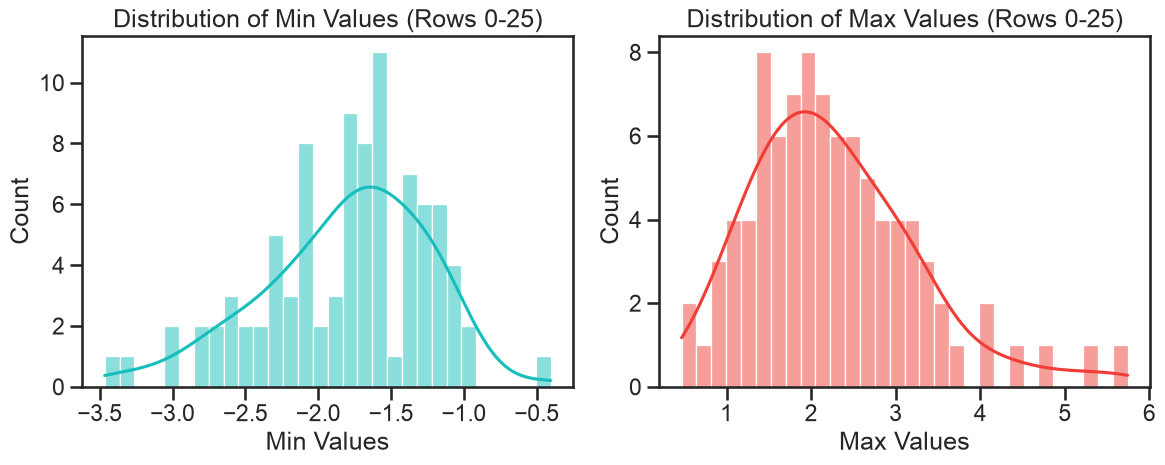

In [10]:
_ = analyze_min_max_distributions(zscores_df, "C7", row_range=(0, N_DISTANCES))

# Quality of the analysis

['A1012', 'A1108', 'A1110', 'A1121', 'A1123', 'B1207', 'B1209', 'B1230', 'B1234', 'B1237', 'L1503']


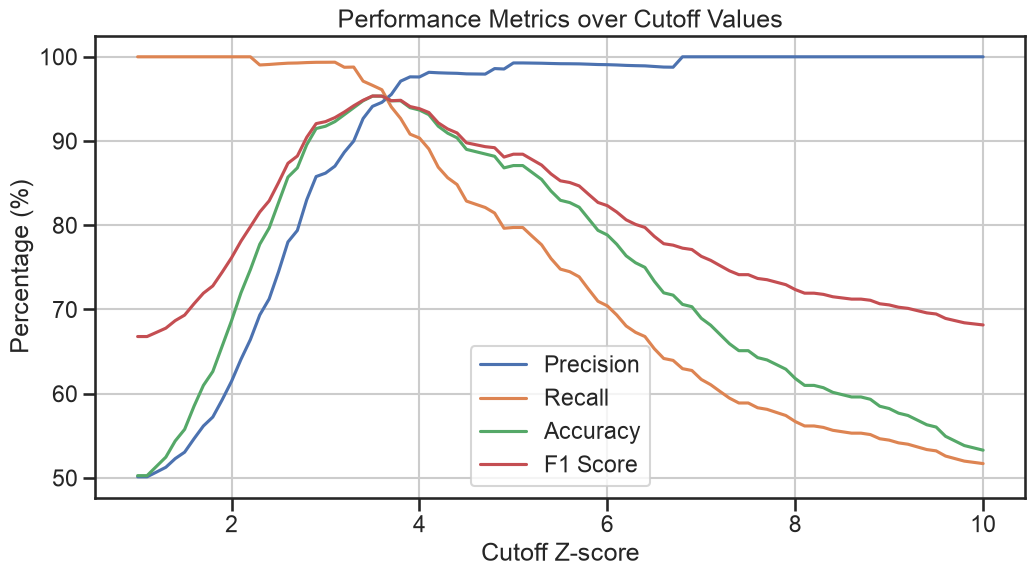

In [11]:
outlier_chlorophylls = find_outlier_chlorophylls(
    zscores_df, "C2", cutoff=3.8, distance=2
)
print(outlier_chlorophylls)

plot_metrics_over_cutoffs(
    zscores_df, start_cutoff=1, end_cutoff=10, step=0.1, distance=2
)

# Check for outliers and values of maximum and minimum Z-scores

A1012
Highest Z-score value: 4.709263121104588
Lowest Z-score value: -3.143281730384529


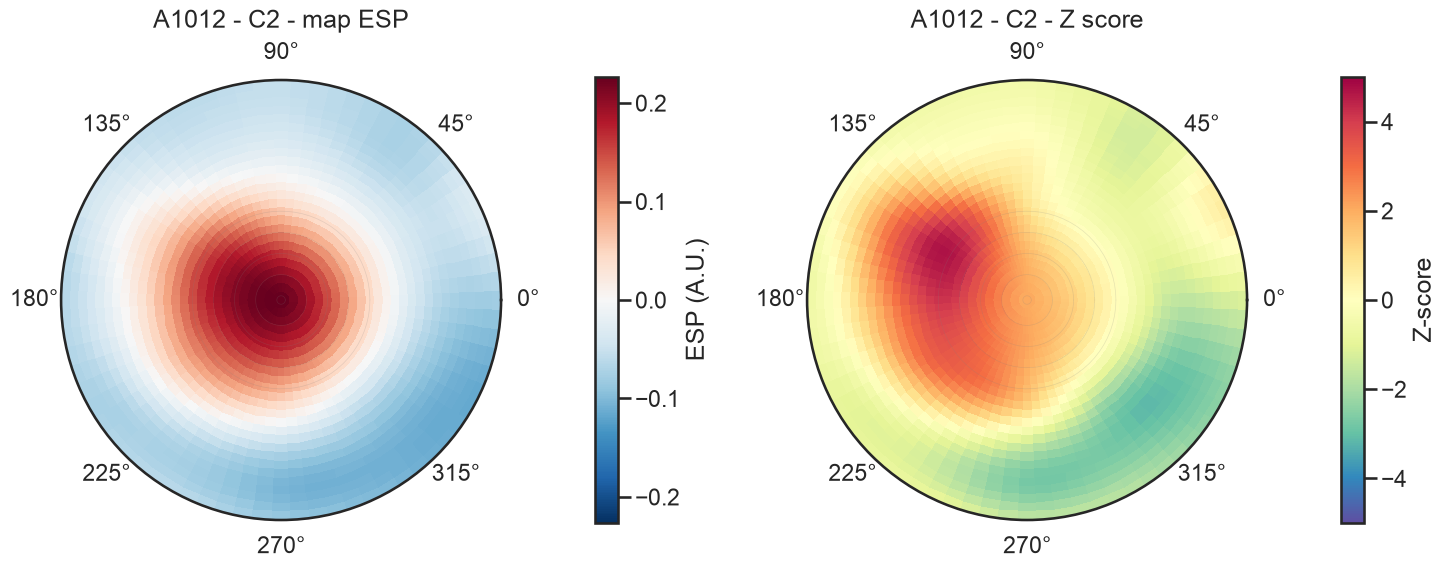

A1108
Highest Z-score value: 4.615155113152819
Lowest Z-score value: -0.9579870802892366


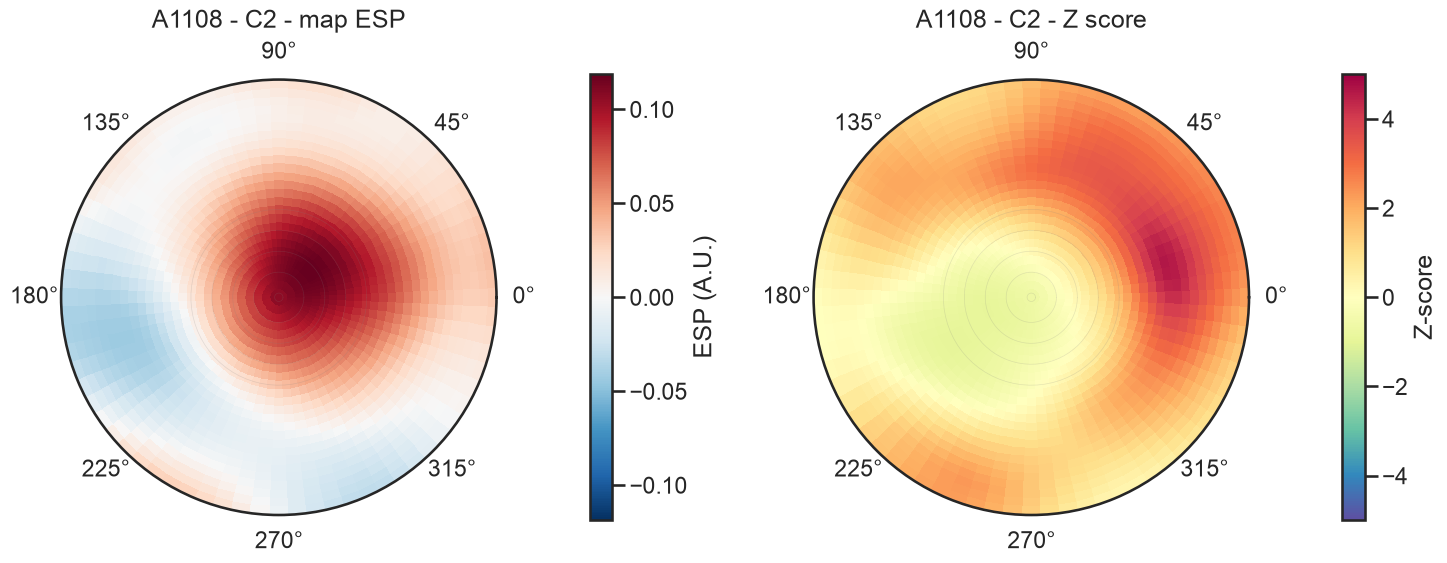

A1110
Highest Z-score value: 5.180719972927104
Lowest Z-score value: -0.838969809633222


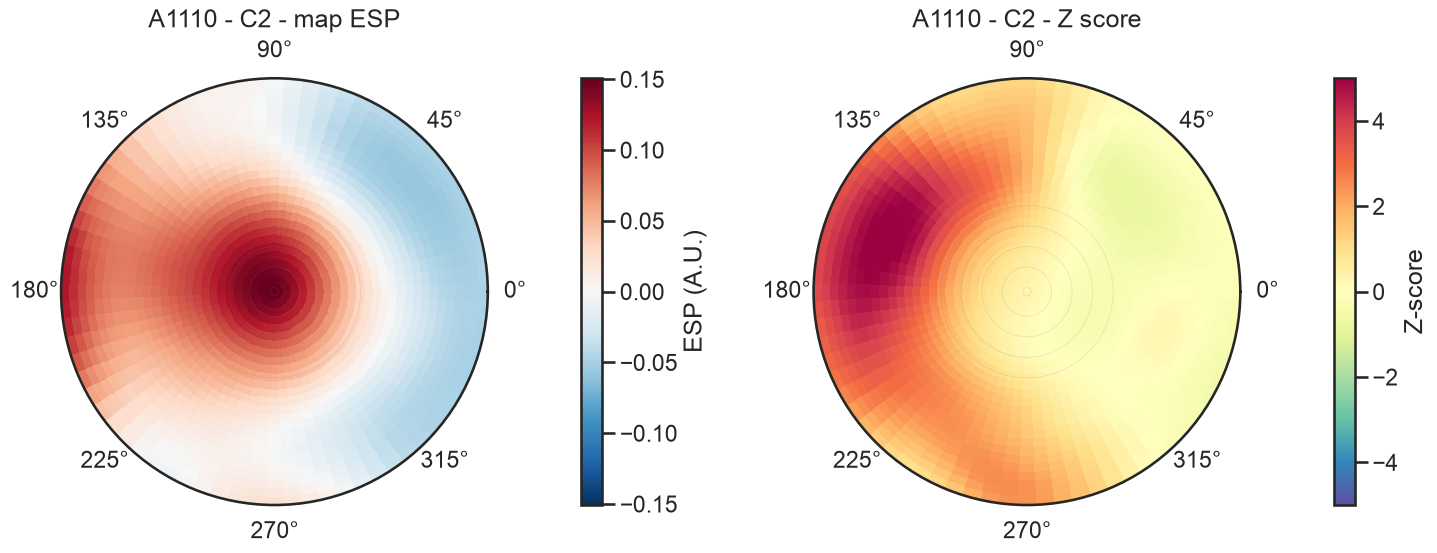

A1121
Highest Z-score value: 4.494096214496606
Lowest Z-score value: -0.6468643500824821


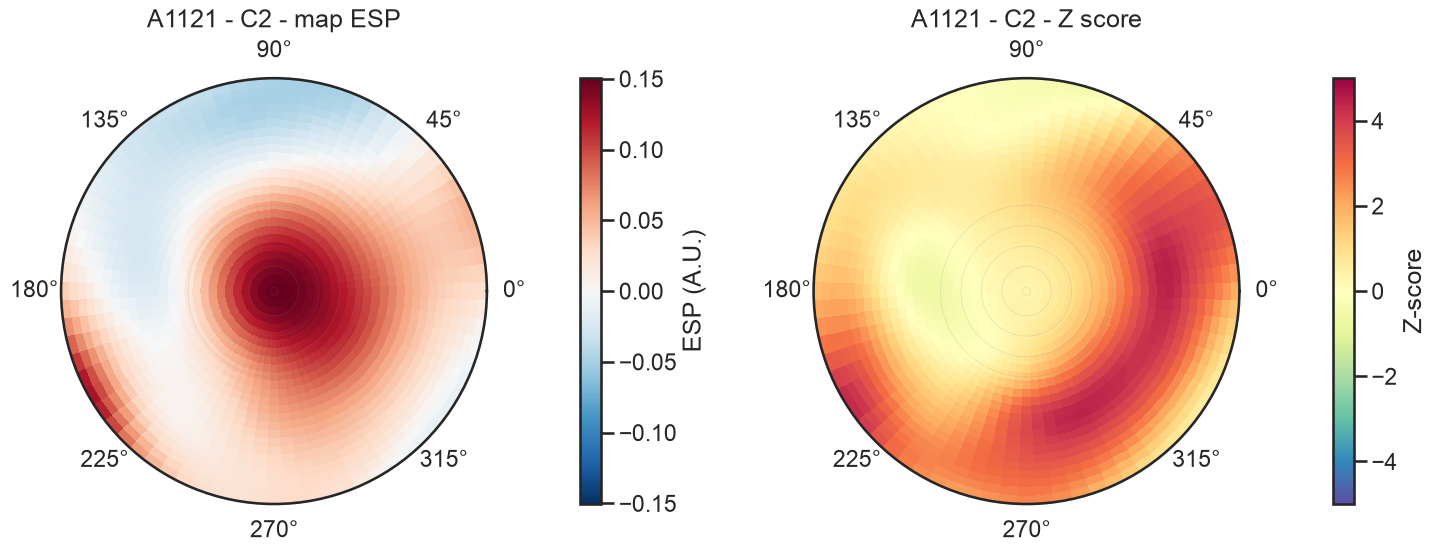

A1123
Highest Z-score value: 4.99251806230155
Lowest Z-score value: -1.6905069025326669


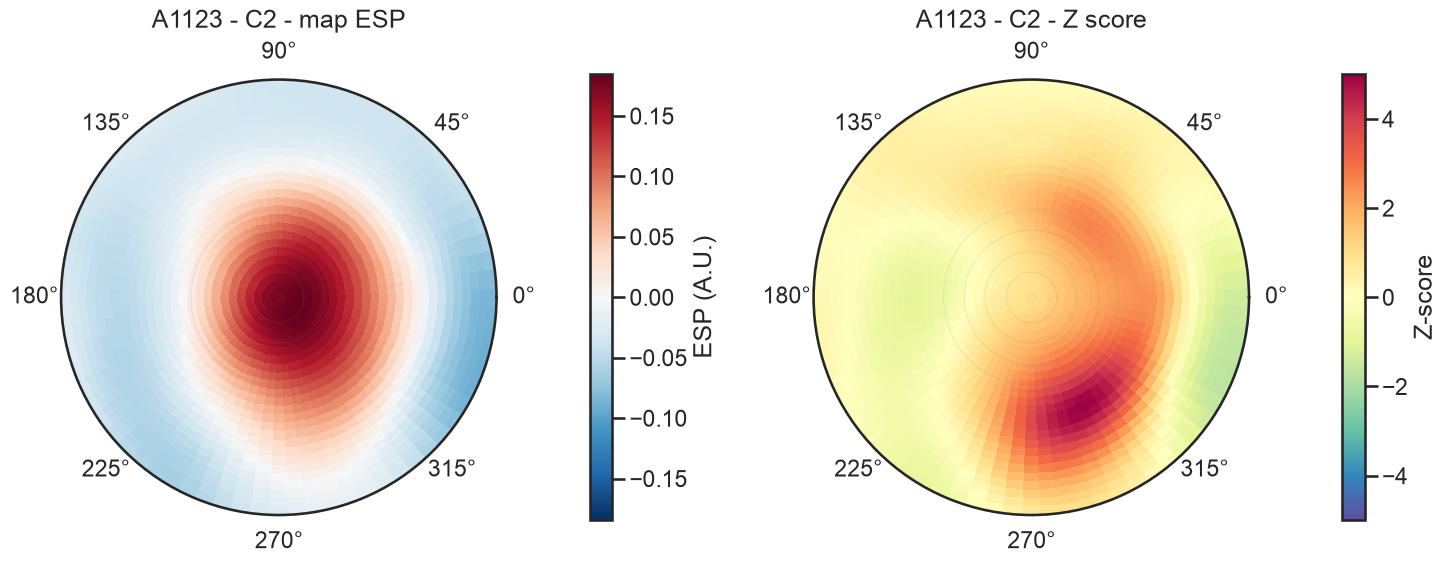

B1207
Highest Z-score value: 8.4262108812938
Lowest Z-score value: -1.4247291466331202


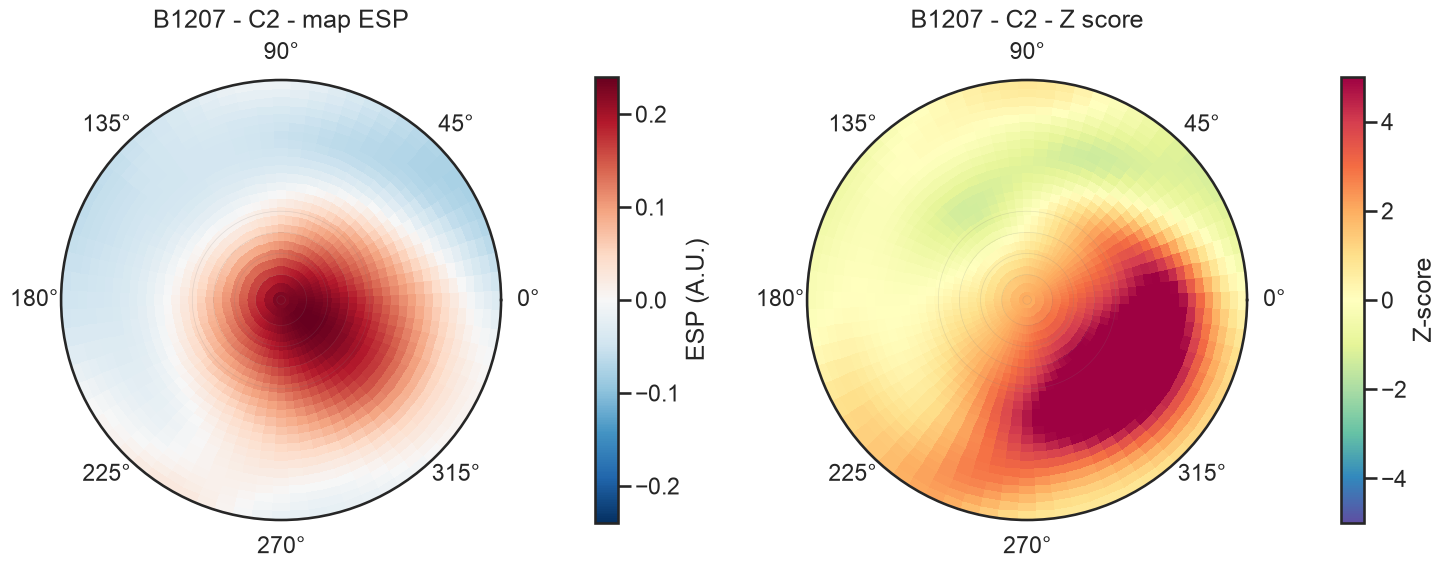

B1209
Highest Z-score value: 5.647086597428638
Lowest Z-score value: -0.7404368919253818


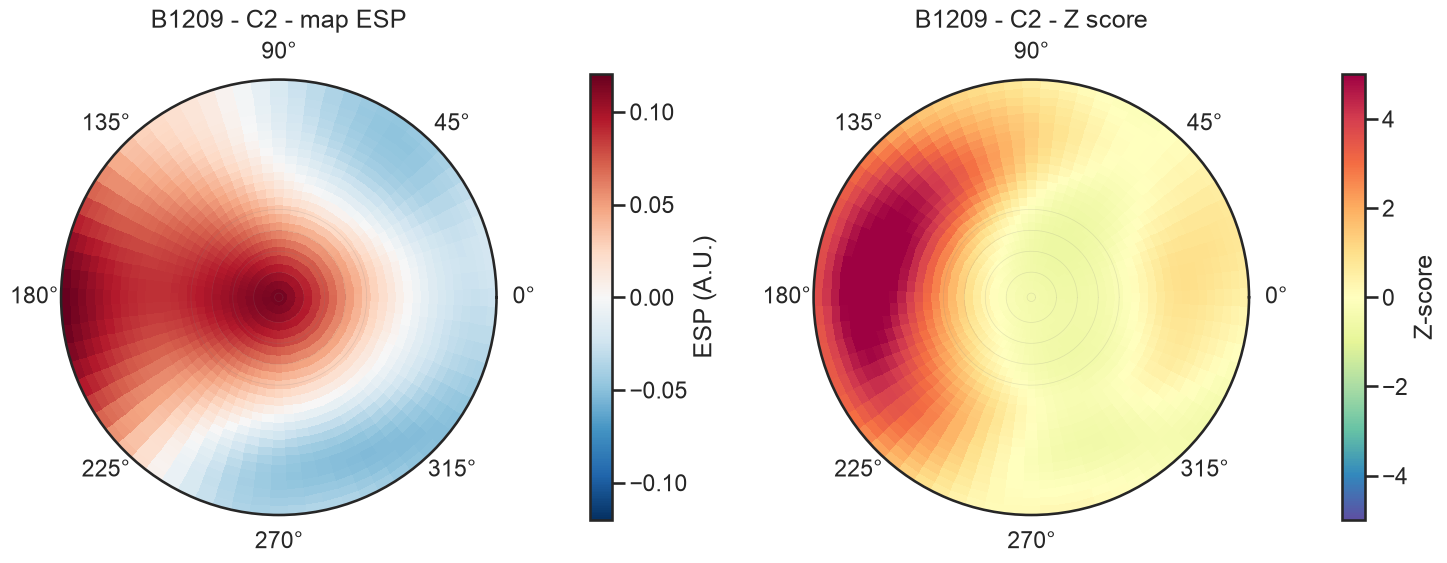

B1230
Highest Z-score value: 4.857459193390811
Lowest Z-score value: -1.842366450153746


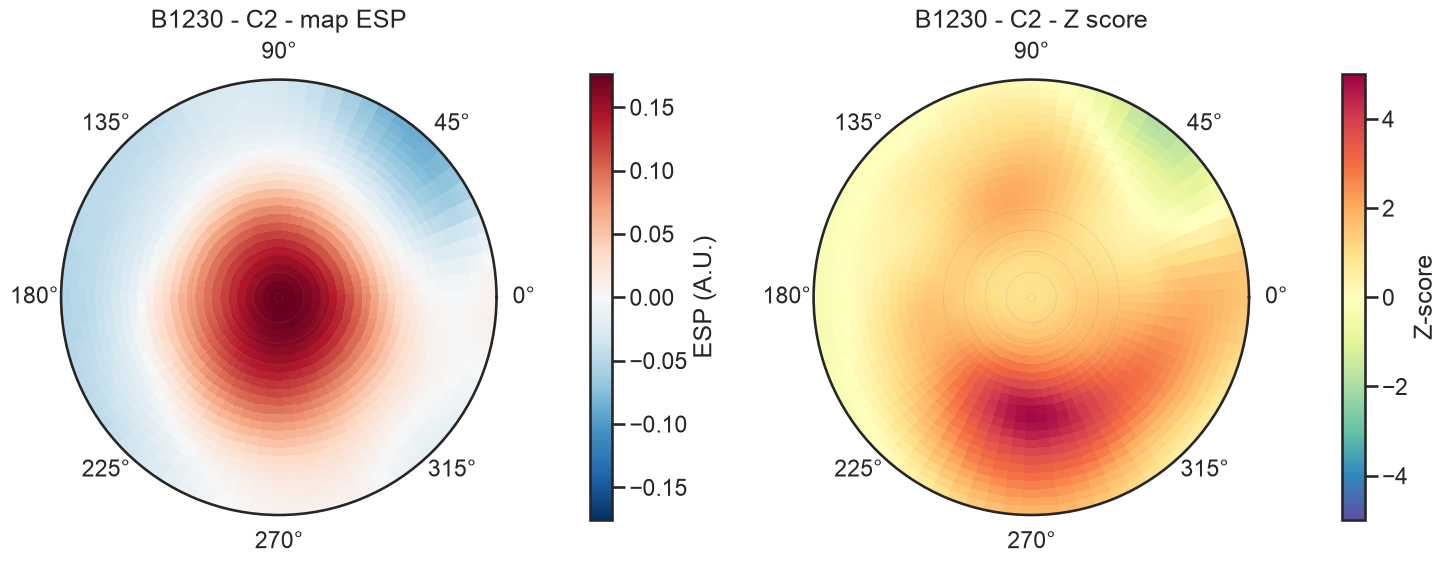

B1237
Highest Z-score value: 7.396968408327038
Lowest Z-score value: -1.6535061326640974


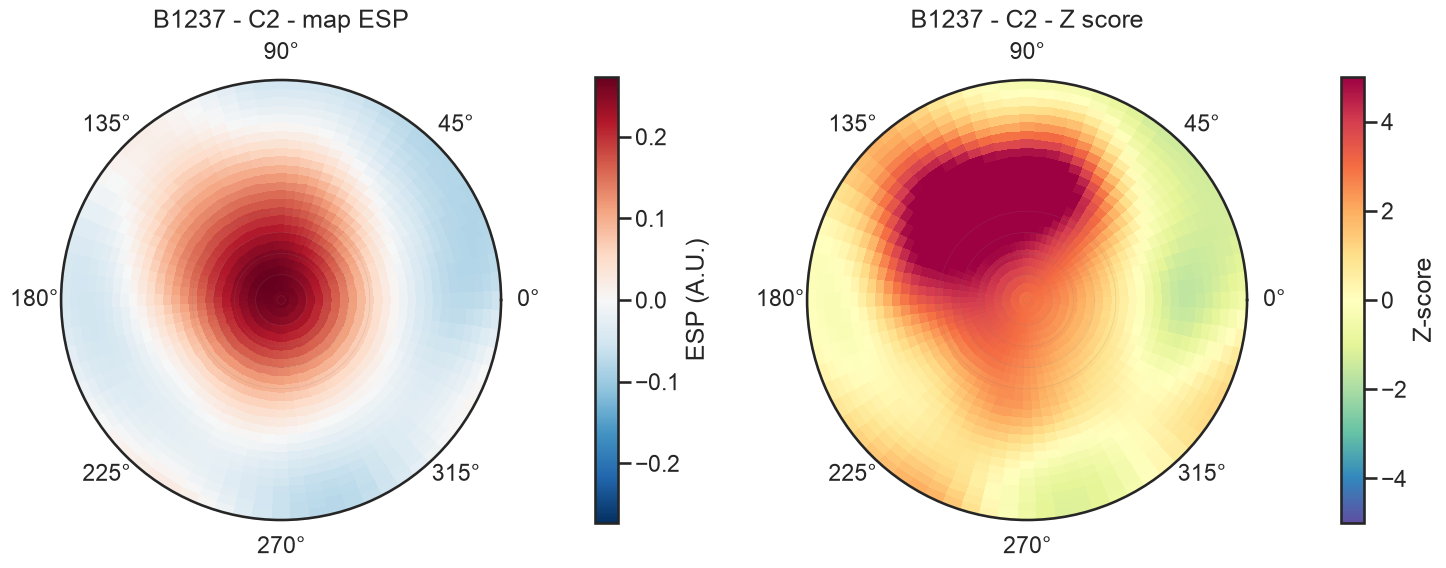

L1503
Highest Z-score value: 4.473505751174998
Lowest Z-score value: -0.8703861075590826


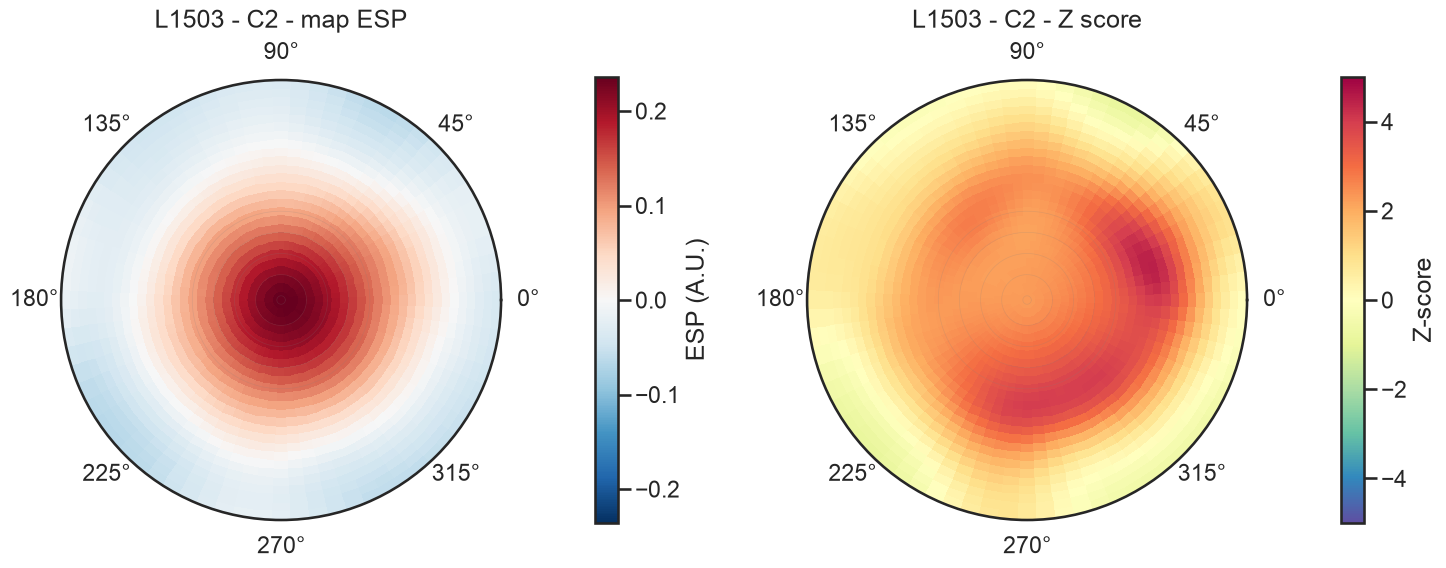

In [12]:
outliers = find_outlier_chlorophylls(zscores_df, "C2", cutoff=4, distance=2)

for candidate in outliers:
    print(candidate)
    print_extreme_values(zscores_df, candidate, "C2")
    polar_plot_substituent(PSII_esp, zscores_df, [candidate], "C2")